# 03 — Exploratory Data Analysis
تحليل استكشافي عام للمتغيرات الرقمية والفئوية والزمنية مع حفظ الجداول والرسومات.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED = Path('../data/processed')
OUT = Path('../visualizations')
OUT.mkdir(parents=True, exist_ok=True)
candidates = [PROCESSED / 'final_dataset.csv', PROCESSED / 'cleaned_transactions.csv']
source = next((p for p in candidates if p.exists()), None)
if source is None:
    raise FileNotFoundError('Add processed data first, then rerun this notebook.')
df = pd.read_csv(source)
print(f'Source: {source.name} | Shape: {df.shape}')

C:\Users\user\AppData\Local\Temp\ipykernel_28244\4189999526.py:13: DtypeWarning: Columns (13,36,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(source)


Source: final_dataset.csv | Shape: (476202, 73)


In [2]:
# Basic numerical summary
numeric = df.select_dtypes(include='number')
numeric_summary = numeric.describe().T
numeric_summary['missing'] = numeric.isna().sum()
numeric_summary.to_csv(PROCESSED / 'numeric_summary.csv')
numeric_summary

,count,mean,std,min,25%,50%,75%,max,missing
amount,476202.0,146.926017,711.057744,0.210000,12.880000,28.34000,68.900000,2.978425e+04,0
merchant_mcc,476202.0,5461.764083,1241.950052,0.000000,5411.000000,5651.00000,5814.000000,8.062000e+03,0
balance_after_transaction,476202.0,10608.100991,35634.967557,-6500.000000,-939.397500,579.92000,4786.130000,4.029551e+05,0
original_amount,476202.0,6.347837,726.051045,-19651.050000,-62.540000,-25.70000,-11.580000,2.978425e+04,0
fx_rate,476202.0,1.000000,0.000000,1.000000,1.000000,1.00000,1.000000,1.000000e+00,0
foreign_fee,476202.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000e+00,0
signed_amount,476202.0,6.347837,726.051045,-19651.050000,-62.540000,-25.70000,-11.580000,2.978425e+04,0
usd_per_unit,476202.0,1.087079,0.113012,1.000000,1.000000,1.00000,1.270000,1.270000e+00,0
amount_usd,476202.0,158.920743,775.154648,0.210000,13.780000,30.56000,75.050000,3.033337e+04,0
signed_amount_usd,476202.0,6.921169,791.247547,-24956.830000,-68.170000,-28.01000,-12.490000,3.033337e+04,0


In [3]:
# Categorical summary: top values and cardinality
categorical = df.select_dtypes(include=['object', 'category', 'bool'])
categorical_summary = pd.DataFrame({
    'unique_values': categorical.nunique(dropna=True),
    'missing': categorical.isna().sum(),
    'top_value': categorical.mode().iloc[0] if not categorical.empty else pd.Series(dtype='object')
})
categorical_summary.to_csv(PROCESSED / 'categorical_summary.csv')
categorical_summary

,unique_values,missing,top_value
transaction_id,476202,0,000008fc40e44902a33669f6cff971ec
account_id,352,0,A00000374
customer_id,200,0,C0000125
transaction_date,469921,0,2024-10-28T08:03:25
currency,3,0,USD
merchant_name,473,0,McDonald's
merchant_category,24,0,groceries
transaction_type,3,0,Withdrawal
payment_channel,6,0,online
city,73,219459,London


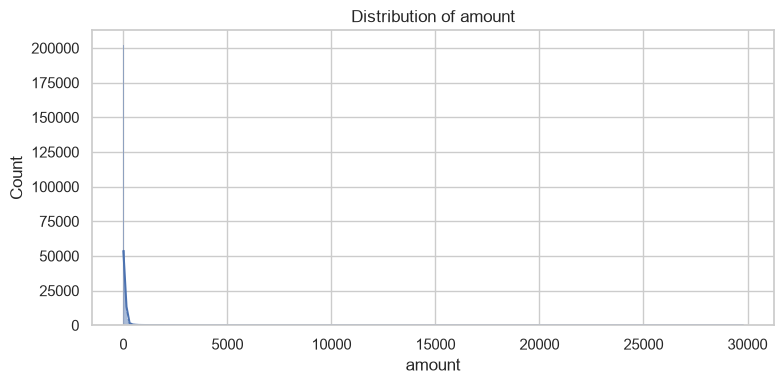

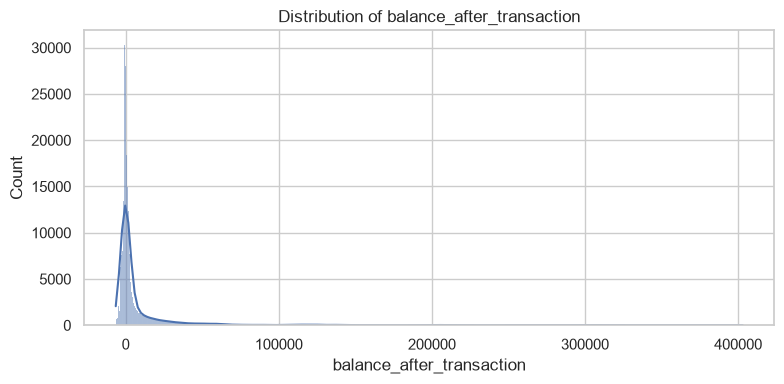

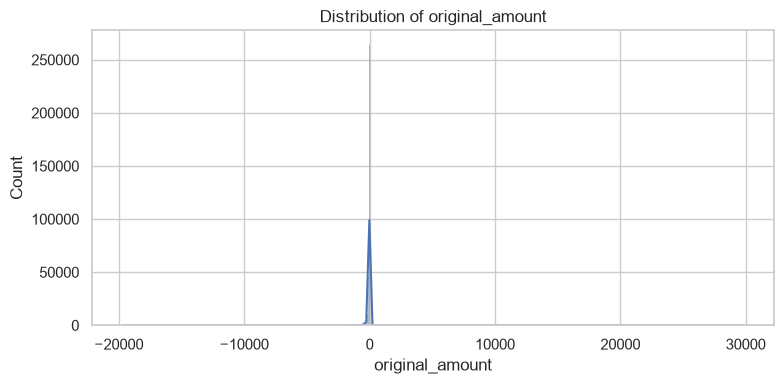

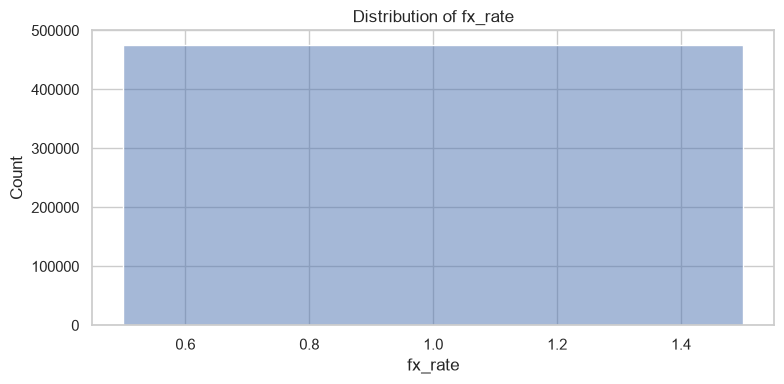

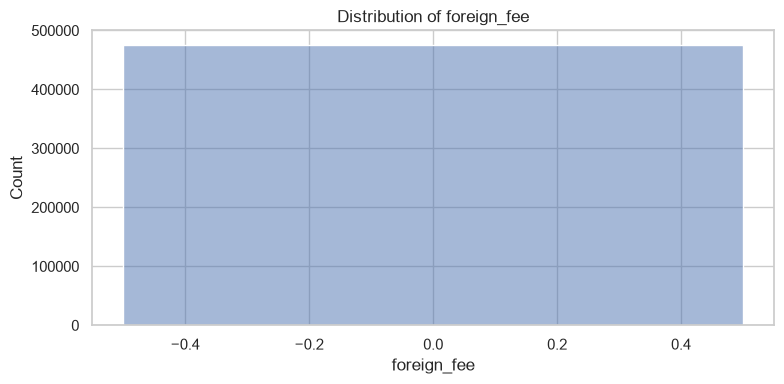

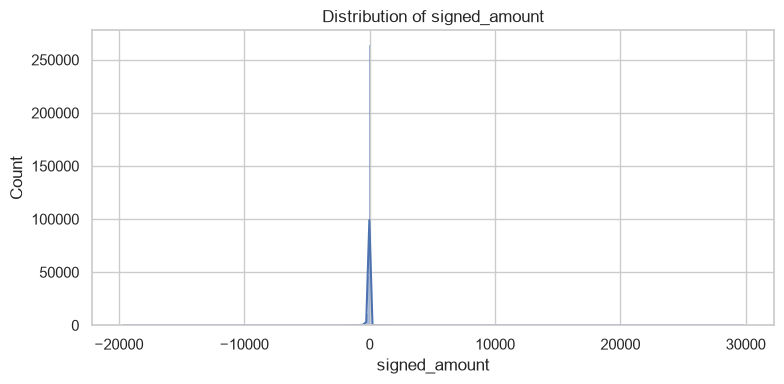

In [4]:
# Distributions for up to six numeric columns
sns.set_theme(style='whitegrid')
measure_cols = [c for c in numeric.columns if not (c.endswith('_id') or c in ('merchant_mcc', 'postal_code'))]
for column in measure_cols[:6]:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(df[column].dropna(), kde=True, ax=ax)
    ax.set_title(f'Distribution of {column}')
    fig.tight_layout()
    fig.savefig(OUT / f'distribution_{column}.png', dpi=150)
    plt.show()
    plt.close(fig)

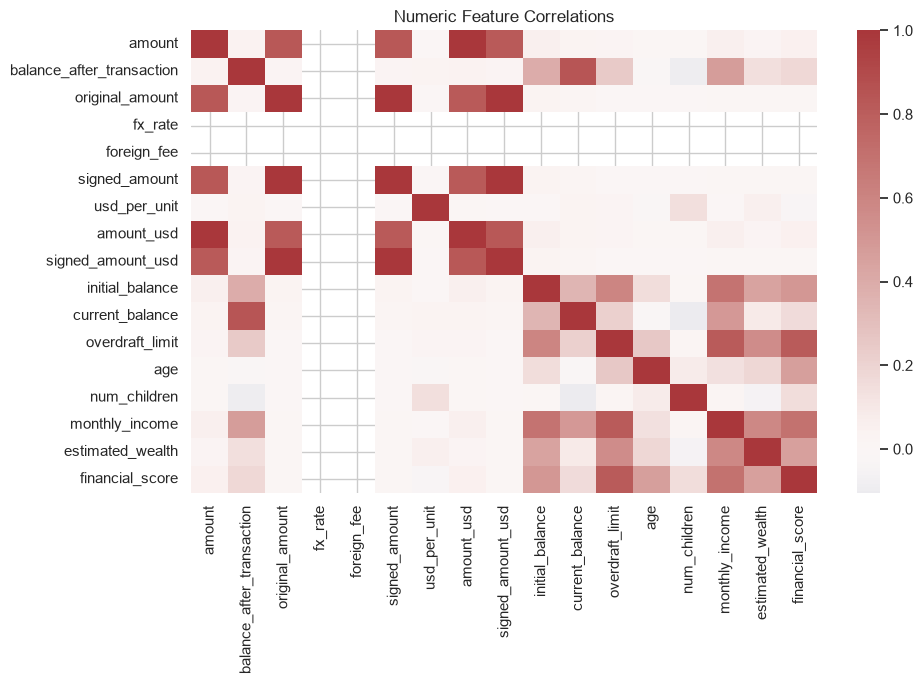

In [5]:
# Correlation heatmap when at least two numeric columns exist
if len(measure_cols) >= 2:
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(numeric[measure_cols].corr(), cmap='vlag', center=0, ax=ax)
    ax.set_title('Numeric Feature Correlations')
    fig.tight_layout()
    fig.savefig(OUT / 'numeric_correlation_heatmap.png', dpi=150)
    plt.show()
    plt.close(fig)

## Interpretation checklist
- Compare mean and median for skewed financial values.
- Check whether missingness is concentrated in specific customer or transaction groups.
- Distinguish correlation from causation.
- Add time-based analysis only after confirming the date column and reporting period.